In [9]:
# Cell No: 1
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [10]:
# Cell No: 2
def load_cifar10():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test

In [11]:
# Cell No: 3
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Classifier
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [12]:
# Cell No: 4
def compile_model(model, learning_rate=0.001):
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
# Cell No: 5
def train_model(model, x_train, y_train, batch_size=64, epochs=20):
    start_time = time.time()

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

    return history, training_time

In [14]:
# Cell No: 6
def evaluate_model(model, x_test, y_test):
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return test_loss, test_acc

In [15]:
# Cell No: 7
import os
from google.colab import drive

# Mount drive (safe to call once)
drive.mount('/content/drive')

def plot_history(history):
    save_dir = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-3/results"
    os.makedirs(save_dir, exist_ok=True)

    file_path = os.path.join(save_dir, "CNN_training_history_cifar10.png")

    plt.figure(figsize=(12, 5))

    # Accuracy subplot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss subplot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()

    # Save figure
    plt.savefig(file_path, dpi=300)
    plt.show()

    print(f"Plot saved at: {file_path}")

Mounted at /content/drive


Loading data...
Building model...
Compiling model...
Training model...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 220ms/step - accuracy: 0.3882 - loss: 1.7034 - val_accuracy: 0.3394 - val_loss: 1.9222
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 213ms/step - accuracy: 0.5268 - loss: 1.3132 - val_accuracy: 0.5144 - val_loss: 1.3726
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 212ms/step - accuracy: 0.6067 - loss: 1.1181 - val_accuracy: 0.5944 - val_loss: 1.1741
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 207ms/step - accuracy: 0.6504 - loss: 0.9922 - val_accuracy: 0.6839 - val_loss: 0.9087
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.6910 - loss: 0.8996 - val_accuracy: 0.6737 - val_loss: 0.9544
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 216ms/step - accuracy: 0.7199 - loss: 0.8052 - val_accuracy: 0.6870 - val_loss: 0.9150
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.7412 - loss: 0.7408 - val_accuracy: 0.7112 - val_loss: 0.8455
Epoch

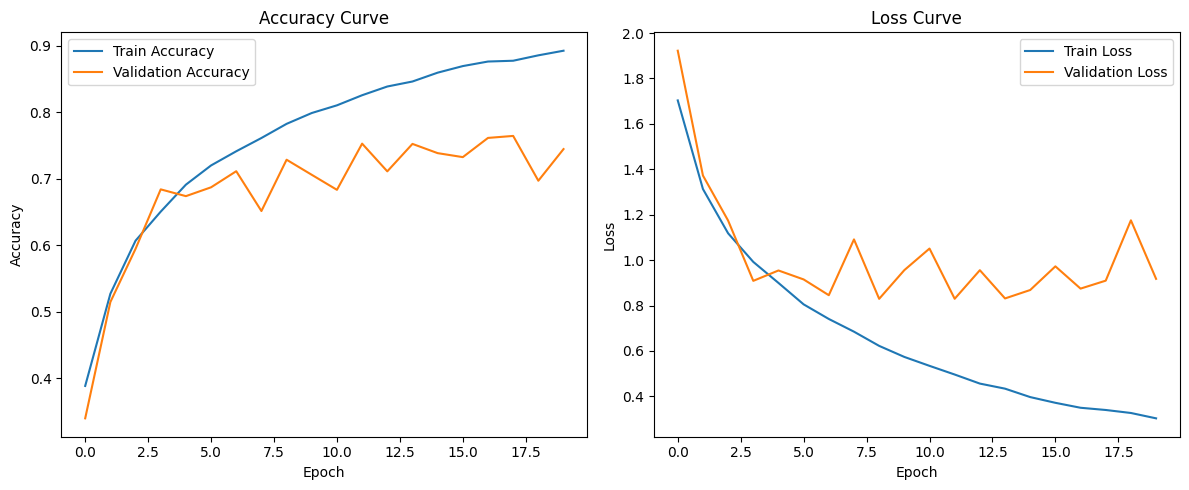

Plot saved at: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-3/results/CNN_training_history_cifar10.png


In [16]:
# Cell No: 8
def main():
    # Hyperparameters
    batch_size = 64
    epochs = 20
    learning_rate = 0.001

    print("Loading data...")
    x_train, y_train, x_test, y_test = load_cifar10()

    print("Building model...")
    model = build_cnn()

    print("Compiling model...")
    model = compile_model(model, learning_rate)

    print("Training model...")
    history, training_time = train_model(
        model, x_train, y_train,
        batch_size=batch_size,
        epochs=epochs
    )

    print("Evaluating model...")
    test_loss, test_acc = evaluate_model(model, x_test, y_test)

    print("\n--- RESULTS ---")
    print(f"Batch Size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Optimizer: Adam")
    print(f"Learning Rate: {learning_rate}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(f"Final Test Loss: {test_loss:.4f}")

    plot_history(history)

# Run
main()